<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/filer-analysis/edgar-filer-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDGAR Filer Analysis

Welcome to the EDGAR Filer Analysis tutorial! Through this tutorial, we aim to offer a comprehensive overview of the trends and factors that have influenced the growth and fluctuations of entities on the SEC EDGAR platform from 1994 to 2022.

By employing various visualization techniques, we'll shed light on the number of EDGAR filers over this time span. Additionally, we'll enrich our dataset by incorporating sector and industry information, SIC codes, and the respective SEC office designations for each filer.

You'll get hands-on experience crafting stacked bar charts, line graphs, heatmaps, box plots, and more to unearth meaningful correlations and insights. Here's a sneak peek of the visualizations you're about to explore:

![gallery](https://i.imgur.com/mlpKOeI.png)

Below, we highlight some of the key observations and insights derived from the EDGAR filer statistics:

- **Peak Filers:** The year 2021 recorded the highest number of EDGAR filers ever.
- **Sectoral Growth:** In 2021, there was a significant influx of new EDGAR filers, second only to 2003. Notably, the industrials and healthcare sectors observed the most pronounced growth.
- **SPAC Surge:** A noticeable surge in Blank cheque companies (SPACs or shell companies) was evident between 2020 and 2022.
- **Tech Sector Warning:** There were anomalous increases in new tech sector filers between 1997 and 1999, hinting at the impending dot-com bubble of 2000.
- **Financial Crisis Precursor:** Between 2003 and 2006, there was a spike in asset-backed securities – a potential early warning sign of the looming financial crisis.
- **Assignment Trends:** Over time, the number of new EDGAR filers linked to specific sectors or industries declined, while unassigned filers saw an uptick.
- **SIC Code Omissions:** Astonishingly, 90% of EDGAR filers are not assigned an SIC code, making them unlinked to any specific SEC office.
- **Assignment Decline:** Beginning in 2000, there was a consistent decline in the number of EDGAR filers associated with a sector, SIC code, or SEC office. This trend was counterbalanced by an increase in filers without any such affiliations.

## Data Sourcing and Preparation

Throughout this section, note that we use the terms `filer` and `entity` interchangeably.

### Data Collection

The annual count of EDGAR filers was determined using the [Query API](https://sec-api.io/docs/query-api). We extracted metadata for all EDGAR filings between 1994 and 2022, which included details like form type (e.g., 10-K) and filing entities (such as CIK, SIC, IRS number, and filer name). By referencing these entities in respective filings for each year, we compiled a comprehensive list. However, a deep dive into the aggregation process will not be covered here. Be prepared: executing the code responsible for this data collection and aggregation can span several days.

### Understanding Multiple Entities

A single filing can encompass multiple entities. Take the insider trading form, **Form 4**, as an example. It always includes at least two entities: the issuer (the company issuing the securities) and the reporter (the individual or entity acquiring or disposing of the securities). Thus, one SEC Form 4 filing, with a unique accession number, results in two separate records in the EDGAR index—one for each entity. Here's an illustrative example showcasing Meta (formerly Facebook) and Mark Zuckerberg as the two entities:

[Form 4 Example](https://www.sec.gov/Archives/edgar/data/1548760/000095010323011806/0000950103-23-011806-index.htm)

![form-4-entities-example](https://i.imgur.com/zNEQx9O.png)

On the other hand, **S-4 filings** can encompass even more entities. The following example houses nine distinct entities:

[S-4 Filing Example](https://www.sec.gov/Archives/edgar/data/1984523/000106569623000087/0001065696-23-000087-index.htm)

![form-s-4-entities-example](https://i.imgur.com/HkDoETF.png)

Key takeaways:
- A single filing can contain multiple entities.
- Every entity will possess a CIK and name, but not all will have an SIC code.

### Dataset Availability

For the sake of convenience, we've prepared the entities dataset in advance. You can freely download the data from the following links:

- [Entities from 1994 to 2011](https://statistics.sec-api.io/tutorials/edgar-filer-analysis/entities_1994_2011.json)
- [Entities from 2012 to 2022](https://statistics.sec-api.io/tutorials/edgar-filer-analysis/entities_2012_2022.json)

The dataset structure is as follows:

```json
{
  "2022": [
    {
      "cik": "789019",
      "companyName": "MICROSOFT CORP (Issuer)",
      "irsNo": "911144442",
      "fiscalYearEnd": "0630",
      "stateOfIncorporation": "WA",
      "sic": "7372 Services-Prepackaged Software",
      "year": "2022"
    },
    {
      "cik": "902012",
      "companyName": "GATES WILLIAM H III (Reporting)",
      "year": "2022"
    }
    // ... additional filers
  ]
  // ... other years
}
```

### Data Enrichment

In the forthcoming steps, we will enhance our dataset by adding sector and industry data for each entity. This is achieved through the [Mapping API](https://sec-api.io/docs/mapping-api), which links each entity's CIK to its corresponding sector and industry. If a mapping isn't available, the value will be represented as "NaN". Furthermore, we will associate the Standard Industrial Classification (SIC) codes of each entity to the appropriate SEC office, as detailed by the SEC's guidelines found [here](https://www.sec.gov/corpfin/division-of-corporation-finance-standard-industrial-classification-sic-code-list).

## Getting Started

As we venture further into our EDGAR Filer Analysis, our next step is crucial: obtaining and processing our primary dataset. In this section, we will walk you through the process of:

1. **Downloading the Entities Data**: We'll programmatically fetch the `entities.json` files which house our essential data spanning from 1994 to 2022.
2. **Conversion to a DataFrame**: The raw JSON data will be transformed into a structured pandas DataFrame. This format is more conducive to the analytical operations we'll be performing.
3. **Enriching the Data**: We'll augment our dataset by appending sector, industry, and SEC office designations to each entity. This added information will give us a richer context as we delve deeper into our analysis.

By the end of this section, you'll have a robust, enriched dataset at your fingertips, ready for detailed exploration and visualization. Let's dive in!

In [ ]:
!pip install -q sec-api

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json
import requests

plt.rcParams.update({'font.size': 9})

In [ ]:
# load entities_1994_2011.json into entities_1994_2011 variable
url_a = "https://statistics.sec-api.io/tutorials/edgar-filer-analysis/entities_1994_2011.json"
response_a = requests.get(url_a)
entities_1994_2011 = response_a.json()

url_b = "https://statistics.sec-api.io/tutorials/edgar-filer-analysis/entities_2012_2022.json"
response_b = requests.get(url_b)
entities_2012_2022 = response_b.json()

# merge entities_1994_2011 and entities_2012_2022 into entities variable
entities_json = {**entities_1994_2011, **entities_2012_2022}

Next, we'll transform the list of entities from the JSON format into a pandas DataFrame. This DataFrame will feature the following columns: `year`, `cik`, `irsNo`, `companyName`, `fiscalYearEnd`, `stateOfIncorporation`, and `sic`.

In [ ]:
def convert_json_to_dataframe(entities_json: dict) -> pd.DataFrame:
    entities_json_list = []

    for year in entities_json.keys():
        for entity in entities_json[year]:
            entity['cik'] = entity['cik'].lstrip('0')
            entity['year'] = year
            entities_json_list.append(entity)

    entities = pd.DataFrame(entities_json_list)

    return entities


entities = convert_json_to_dataframe(entities_json)
entities.drop(labels=['act', 'fileNo', 'type', 'filmNo'], axis=1, inplace=True)
year = entities['year']
entities.drop(labels=['year'], axis=1, inplace=True)
entities.insert(0, 'year', year)
entities['year'] = entities['year'].astype(int)

In [ ]:
print('All EDGAR entities from 1994 - 2022')
entities # 3056738 rows

All EDGAR entities from 1994 - 2022


,year,fiscalYearEnd,stateOfIncorporation,cik,companyName,sic,irsNo
0,1994,1231,LA,96035,SYSTEM FUELS INC (Filer),0000,NaN
1,1994,1130,NaN,89954,TRUST FOR SHORT TERM U S GOVERNMENT SECURITIES...,NaN,251289316
2,1994,0331,MA,901823,PUTNAM MANAGED HIGH YIELD TRUST (Filer),0000,046733967
3,1994,1231,NY,872243,EMPIRE STATE MUNICIPAL EXEMPT TRUST GUARANTEED...,0000,NaN
4,1994,1231,NY,872246,EMPIRE STATE MUNICIPAL EXEMPT TRUST GUARANTEED...,0000,NaN
...,...,...,...,...,...,...,...
3056733,2022,1231,NY,1956590,GO UES Investors LLC (Filer),NaN,920625088
3056734,2022,1231,T2,1955130,Broomfield International Ltd (Filed by),NaN,000000000
3056735,2022,1231,DE,1895349,"Bridger Healthcare SIV I, LP (Filer)",NaN,000000000
3056736,2022,NaN,NaN,1830807,Eden Douglas Todd (Filed by),NaN,NaN


### Augmenting with Sector & Industry Data

To further enrich our dataset, we'll incorporate sector and industry information for each entity using the Mapping API. Start by retrieving the mapping data for all CIKs available in the mapping database. Once obtained, we'll associate the CIKs from our entities DataFrame with their respective sectors and industries. This is achieved using pandas' `df_A.merge(df_B)` function, allowing us to seamlessly append the `sector` and `industry` columns to our DataFrame.

In [ ]:
from sec_api import MappingApi

mappingApi = MappingApi(api_key='YOUR_API_KEY')

In [ ]:
mappings_json = mappingApi.resolve('cik', '[0-9]')

In [ ]:
mappings = pd.DataFrame(mappings_json).drop(columns=["id"])
mappings["cik"] = mappings["cik"].astype(str)
mappings[mappings["sector"] == ""] = np.nan
mappings[mappings["industry"] == ""] = np.nan

The `mappings` DataFrame comprises 16 columns. Among these, the `cik`, `sector`, and `industry` columns are most important for our analysis.



In [ ]:
print(f"Number of mappings: {len(mappings)}")
mappings.head()

Number of mappings: 41847


,name,ticker,cik,cusip,exchange,isDelisted,category,sector,industry,sic,sicSector,sicIndustry,famaSector,famaIndustry,currency,location
0,AGILENT TECHNOLOGIES INC,A,1090872,00846U101,NYSE,False,Domestic Common Stock,Healthcare,Diagnostics & Research,3826,Manufacturing,Laboratory Analytical Instruments,,Measuring and Control Equipment,USD,California; U.S.A
1,ALCOA CORP,AA,1675149,013872106,NYSE,False,Domestic Common Stock,Basic Materials,Aluminum,3334,Manufacturing,Primary Production Of Aluminum,,Steel Works Etc,USD,Pennsylvania; U.S.A
2,ADMIRALTY BANCORP INC,AAAB,1066808,007231103,NASDAQ,True,Domestic Common Stock,Financial Services,Banks - Regional,6022,Finance Insurance And Real Estate,State Commercial Banks,,Banking,USD,Florida; U.S.A
3,ALTANA AKTIENGESELLSCHAFT,AAAGY,1182802,02143N103,NYSE,True,ADR Common Stock,Healthcare,Biotechnology,2834,Manufacturing,Pharmaceutical Preparations,,Pharmaceutical Products,EUR,Jordan
4,ADVANCED ACCELERATOR APPLICATIONS SA,AAAP,1611787,00790T100,NASDAQ,True,ADR Common Stock,Healthcare,Biotechnology,2834,Manufacturing,Pharmaceutical Preparations,,Pharmaceutical Products,EUR,France


In [ ]:
tmp_mappings = mappings.dropna(subset=['sector', 'industry'])
print(f"{len(entities)} filers before merging")
entities = entities.merge(tmp_mappings[['cik', 'sector', 'industry']].drop_duplicates(subset=['cik']), how='left', on='cik')
entities.drop_duplicates(inplace=True)
entities.reset_index(drop=True, inplace=True)
print(f"{len(entities)} filers after merging")

3056738 filers before merging
3056738 filers after merging


Upon merging the sector and industry data into our `entities` DataFrame, the final list of entities looks like this:

In [ ]:
entities[entities['year']==2022].head()

,year,fiscalYearEnd,stateOfIncorporation,cik,companyName,sic,irsNo,sector,industry
2898221,2022,1231,DE,19617,JPMORGAN CHASE & CO (Filer),6021 National Commercial Banks,132624428,Financial Services,Banks - Diversified
2898222,2022,1231,DE,1665650,JPMorgan Chase Financial Co. LLC (Filer),6021 National Commercial Banks,475462128,NaN,NaN
2898223,2022,1231,X0,312070,BARCLAYS BANK PLC (Filer),"6029 Commercial Banks, NEC",000000000,NaN,NaN
2898224,2022,NaN,NaN,1504477,Blend L Michael (Reporting),NaN,NaN,NaN,NaN
2898225,2022,1231,DE,1805833,"System1, Inc. (Issuer)","7370 Services-Computer Programming, Data Proce...",981531250,Industrials,Specialty Business Services


### Augmenting with SIC Codes and SEC Offices

Our next enhancement involves associating SIC codes with their respective SEC Offices. Fortunately, the SEC website provides a detailed mapping between SIC codes and SEC offices, which can be found here: [SEC SIC Code List](https://www.sec.gov/corpfin/division-of-corporation-finance-standard-industrial-classification-sic-code-list).

For ease of access, we've already extracted and converted this mapping, inclusive of SIC codes, SEC office designations, and industry titles, into a JSON file. You can fetch it directly from: [SIC-to-Office Mapping JSON](https://statistics.sec-api.io/tutorials/edgar-filer-analysis/sic-codes-list.json).

In this section, we'll:

1. Download the provided JSON file.
2. Separate the SIC column in our `entities` DataFrame into two distinct columns: `sic_code` (housing the 3-4 digit code) and `sic_industry` (containing the industry title).
3. Integrate the SIC-to-Office mapping with our `entities` DataFrame.

Post these steps, our enriched `entities` DataFrame will feature an additional `office` column, indicating the designated SEC office for each entry.

In [ ]:
sic_code_url = "https://statistics.sec-api.io/tutorials/edgar-filer-analysis/sic-codes-list.json"
sic_code_response = requests.get(sic_code_url)
sic_codes_json = sic_code_response.json()

In [ ]:
sic_codes = pd.DataFrame(sic_codes_json)
sic_codes['sic_code'] = sic_codes['sic_code'].astype(str)

In [ ]:
sic_codes

,sic_code,office,industry_title
0,100,Industrial Applications and Services,AGRICULTURAL PRODUCTION-CROPS
1,200,Industrial Applications and Services,AGRICULTURAL PROD-LIVESTOCK & ANIMAL SPECIALTIES
2,700,Industrial Applications and Services,AGRICULTURAL SERVICES
3,800,Industrial Applications and Services,FORESTRY
4,900,Industrial Applications and Services,"FISHING, HUNTING AND TRAPPING"
...,...,...,...
439,8880,Office of International Corp Fin,AMERICAN DEPOSITARY RECEIPTS
440,8888,Office of International Corp Fin,FOREIGN GOVERNMENTS
441,8900,Office of Trade & Services,"SERVICES-SERVICES, NEC"
442,9721,Office of International Corp Fin,INTERNATIONAL AFFAIRS


In [ ]:
# split "sic" column in sic_stats into "sic_code" and "sic_industry" columns by splitting at first space
entities[['sic_code', 'sic_industry']] = entities['sic'].str.split(n=1, expand=True)
entities['sic_code'] = entities['sic_code'].str.lstrip('0')
entities['sic_code'].replace('', np.nan, inplace=True)
entities['sic_industry'].replace({None: np.nan}, inplace=True)

In [ ]:
print(f"{len(entities)} filers before merging")
entities = entities.merge(sic_codes[['sic_code', 'office']], how='left', on='sic_code')
entities.reset_index(drop=True, inplace=True)
print(f"{len(entities)} filers after merging")

3056738 filers before merging
3056738 filers after merging


We're set! Our `entities` DataFrame now encompasses sector and industry details for each EDGAR entity, complemented by the designated SEC Office, SIC code, and SIC industry title. With this enriched dataset in hand, we're ready to delve into visualization and analysis.

In [ ]:
entities[entities['year']==2022].head()

,year,fiscalYearEnd,stateOfIncorporation,cik,companyName,sic,irsNo,sector,industry,sic_code,sic_industry,office
2898221,2022,1231,DE,19617,JPMORGAN CHASE & CO (Filer),6021 National Commercial Banks,132624428,Financial Services,Banks - Diversified,6021,National Commercial Banks,Office of Finance
2898222,2022,1231,DE,1665650,JPMorgan Chase Financial Co. LLC (Filer),6021 National Commercial Banks,475462128,NaN,NaN,6021,National Commercial Banks,Office of Finance
2898223,2022,1231,X0,312070,BARCLAYS BANK PLC (Filer),"6029 Commercial Banks, NEC",000000000,NaN,NaN,6029,"Commercial Banks, NEC",Office of Finance
2898224,2022,NaN,NaN,1504477,Blend L Michael (Reporting),NaN,NaN,NaN,NaN,NaN,NaN,NaN
2898225,2022,1231,DE,1805833,"System1, Inc. (Issuer)","7370 Services-Computer Programming, Data Proce...",981531250,Industrials,Specialty Business Services,7370,"Services-Computer Programming, Data Processing...",Office of Technology


## Visualizing EDGAR Filers' Trends

It's time to bring our data to life through visualization. In this section, we'll illustrate the trajectory of EDGAR filers over the years.

1. **Annual EDGAR Filers**: A bar chart will showcase the number of entities that filed an EDGAR filing from 1994 to 2022.
2. **New vs. Total Filers**: We'll compute the yearly count of new EDGAR filers and contrast this against the cumulative total using compelling visuals.
3. **Growth Analysis**: To further understand the dynamics, we'll calculate and visualize the year-on-year percentage growth in new filers.

These visualizations will not only offer a bird's-eye view of the trends but also equip us with insights into the nuances of filer growth and the factors influencing them.

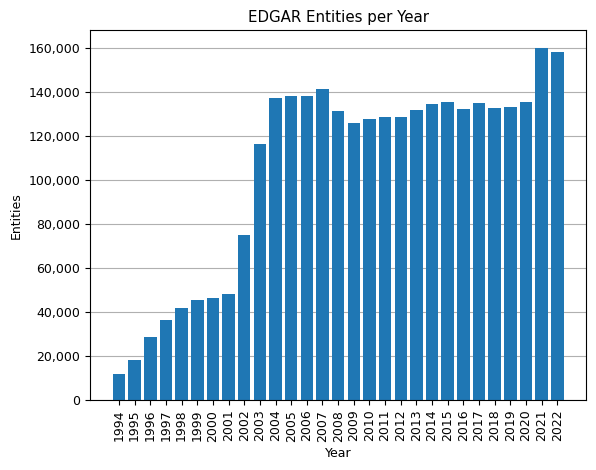

In [ ]:
years = entities['year'].unique().tolist()
num_entities = entities.groupby('year').size().tolist()

plt.bar(years, num_entities)
plt.xlabel('Year'), plt.ylabel('Entities'), plt.title('EDGAR Entities per Year')
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(years, rotation=90), plt.grid(axis='y'), plt.gca().set_axisbelow(True)
plt.show()

Let us now find entities that are seen for the first time in each year, allowing us to track when each entity first appeared in the dataset.

For this, we define the function `get_new_filers_per_year` that processes the `entities` dataframe to identify new entities (or 'filers') for each year, i.e., entities that are seen for the first time in that year.

In [ ]:
def get_new_filers_per_year(entities):
    new_filers = None
    processed_ciks = set()
    years = entities['year'].unique().tolist()

    for year in years:
        ciks = entities[entities['year'] == year]['cik'].tolist()
        if year == 1994:
            new_filers = pd.DataFrame(entities[entities['year'] == year])
            processed_ciks.update(ciks)
            continue

        year_entities = entities[entities['year'] == year]
        new_filers_for_year = year_entities[~year_entities['cik'].isin(processed_ciks)]
        new_filers = pd.concat([new_filers, new_filers_for_year], ignore_index=True)

        processed_ciks.update(ciks)

    return new_filers

In [ ]:
new_filers = get_new_filers_per_year(entities)

In [ ]:
print('New EDGAR entities in 2020:', len(new_filers[new_filers['year'] == 2020])) # 35055

New EDGAR entities in 2020: 35055


The next code snippet is designed to visualize the distribution of entities over the years, specifically highlighting the difference between all entities and the new entities added each year.

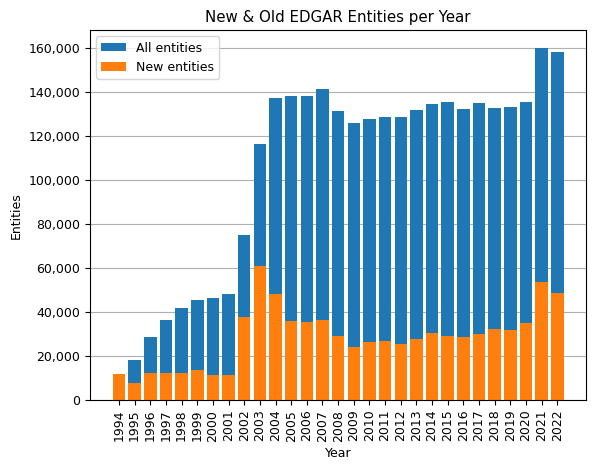

In [ ]:
years = entities['year'].unique().tolist()
num_entities = entities.groupby('year').size().tolist()
num_new_filers = new_filers.groupby('year').size().tolist()

plt.bar(years, num_entities, label='All entities')
plt.bar(years, num_new_filers, label='New entities')
plt.xlabel('Year'), plt.ylabel('Entities'), plt.title('New & Old EDGAR Entities per Year')
plt.legend()
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(years, rotation=90), plt.grid(axis='y'), plt.gca().set_axisbelow(True)
plt.show()

In [ ]:
years = entities['year'].unique().tolist()

filers_df = pd.DataFrame({'total filers': num_entities, 'new filers': num_new_filers}, index=sorted(years))
filers_df['new filers %'] = filers_df['new filers'] / filers_df['total filers'] * 100
filers_df['new filers %'] = filers_df['new filers %'].map('{:,.1f}'.format)
filers_df['filers growth YoY'] = filers_df['total filers'].pct_change() * 100
filers_df['filers growth YoY'] = filers_df['filers growth YoY'].map('{:,.1f}'.format)
filers_df['new filers growth YoY'] = filers_df['new filers'].pct_change() * 100
filers_df['new filers growth YoY'] = filers_df['new filers growth YoY'].map('{:,.1f}'.format)
filers_df = filers_df.sort_index(ascending=False)

filers_df.head()

,total filers,new filers,new filers %,filers growth YoY,new filers growth YoY
2022,158517,48682,30.7,-1.0,-9.4
2021,160186,53713,33.5,18.3,53.2
2020,135393,35055,25.9,1.4,10.3
2019,133494,31783,23.8,0.5,-1.2
2018,132826,32173,24.2,-1.7,7.9


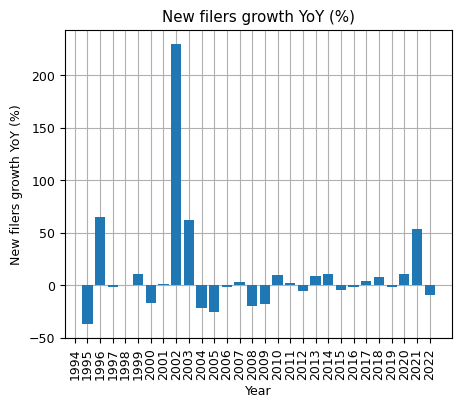

In [ ]:
filers_df['new filers growth YoY'] = filers_df['new filers growth YoY'].astype(float)
plt.figure(figsize=(5, 4)), plt.bar(filers_df.index, filers_df['new filers growth YoY'])
plt.title('New filers growth YoY (%)'), plt.xlabel('Year'), plt.ylabel('New filers growth YoY (%)')
plt.grid(axis='y'), plt.grid(axis='x')
plt.gca().set_axisbelow(True), plt.xticks(filers_df.index, rotation=90)
plt.show()

Let's summarize the insights from the EDGAR filer's data so far collected:

1. The year 2021 marked an all-time high in the number of EDGAR entities, reaching a pinnacle of 160,186 filers. The year recorded a 53% surge in new filers relative to 2020.
2. 2021 recorded the second-highest count of newcomers to the EDGAR platform.
3. While 2022 experienced a slight dip in new filers compared to its preceding year, it still ranks third in the all-time highest new filer counts.
4. Despite the challenges of the COVID-19 pandemic in 2020, both new and total EDGAR filers saw an upward trend compared to 2019.
5. The record for the most significant number of new filers goes to 2003, standing second only to 2021, while 2002 witnessed a staggering 230% growth in new filers when contrasted with 2001. It's worth noting that the subsequent year, 2004, witnessed the enforcement of the Sarbanes-Oxley Act, which augmented reporting norms for public entities. This legislative change possibly fueled the surge in new filers in 2003.
6. The global financial crisis had a visible impact on EDGAR's metrics. For the first time since EDGAR's inception in 1994, the total number of entities declined during 2008 and 2009.
7. A consistent year-on-year decrease in new filers was observed from 2003 to 2009.
8. Post-2009, from 2010 onwards, there has been a gradual year-on-year increase in both new and overall entities on EDGAR.

## Sector and Industry Analysis of EDGAR Filers

In this section, we'll focus on a detailed analysis of EDGAR filers segmented by sectors and industries from 1994 to 2022. Our approach will involve:

1. **Data Segmentation**: Utilizing pivot tables, we'll categorize the number of EDGAR filers per sector and industry over the specified timeframe.
2. **Visualization**: Stacked bar charts and line charts will be employed to represent the distribution and trends of filers across different sectors and industries.
3. **Anomaly Detection**: We'll also examine the data for any anomalies which might indicate underlying market trends or significant events.

In [ ]:
sector_stats = entities.groupby(['year', 'sector'], dropna=False).cik.count().reset_index(name='cik_count')
sector_stats[sector_stats['year'] == 2022].sort_values(by='cik_count', ascending=False).head(20)

,year,sector,cik_count
347,2022,NaN,151476
342,2022,Healthcare,1461
343,2022,Industrials,1360
345,2022,Technology,934
341,2022,Financial Services,921
338,2022,Consumer Cyclical,631
336,2022,Basic Materials,374
344,2022,Real Estate,315
340,2022,Energy,308
337,2022,Communication Services,303


We've segmented the data into 12 unique sectors, one of which is the 'NaN' category. This category encompasses entities that haven't been designated a specific sector, such as trusts or insiders often documented in Form 4.

From the 2022 snapshot generated, we can observe the distribution of EDGAR filers across these 12 sectors. The 'NaN' category stands out with a substantial count of 151,477 entities. However, looking beyond this, the 'Healthcare' sector is prominently represented with 1,461 entities, closely trailed by the 'Industrials' sector with 1,360 entities. Such figures indicate a high level of activity and growth in these sectors. Additionally, the 'Technology' and 'Financial Services' sectors remain influential with 934 and 920 entities, respectively. On the other end of the spectrum, the strictly regulated 'Utilities' sector has the least presence, with only 138 entities for 2022.



To examine the distribution of filers across sectors over the years, we construct a pivot table. This table designates years as the index column and sectors as column labels. Each cell within this matrix indicates the quantity of EDGAR filers corresponding to a specific sector for a particular year.

In [ ]:
sector_stats_pivot = sector_stats.pivot(index='year', columns='sector', values='cik_count')
sector_stats_pivot[-10:]

sector,NaN,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
year,,,,,,,,,,,,
2013,124658,452,370,725,311,453,1087,1158,800,337,1250,140
2014,128024,426,324,639,296,455,1078,1178,744,337,1062,146
2015,129015,415,310,622,296,451,1035,1203,742,343,1040,148
2016,126135,407,300,612,281,430,1019,1185,731,340,966,150
2017,128784,402,301,608,280,433,980,1213,738,340,920,151
2018,126555,387,295,599,268,415,978,1272,718,335,861,143
2019,127300,378,295,604,270,387,941,1292,719,325,848,135
2020,128845,364,302,621,276,361,955,1403,918,320,891,137
2021,153015,375,319,644,297,339,954,1485,1344,318,958,138


Let's start by visualizing the data to get a clearer sense of the trends. Once we have the visual representation, we can identify and list the key insights.

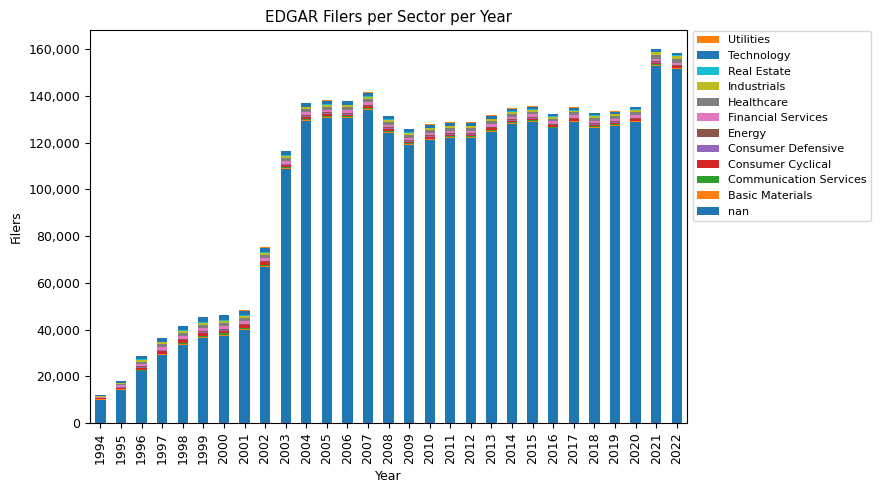

In [ ]:
sector_stats_pivot.plot(kind='bar', stacked=True, figsize=(7, 5))
plt.title("EDGAR Filers per Sector per Year")
plt.ylabel("Filers"), plt.xlabel("Year"), plt.tight_layout()
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='lower left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

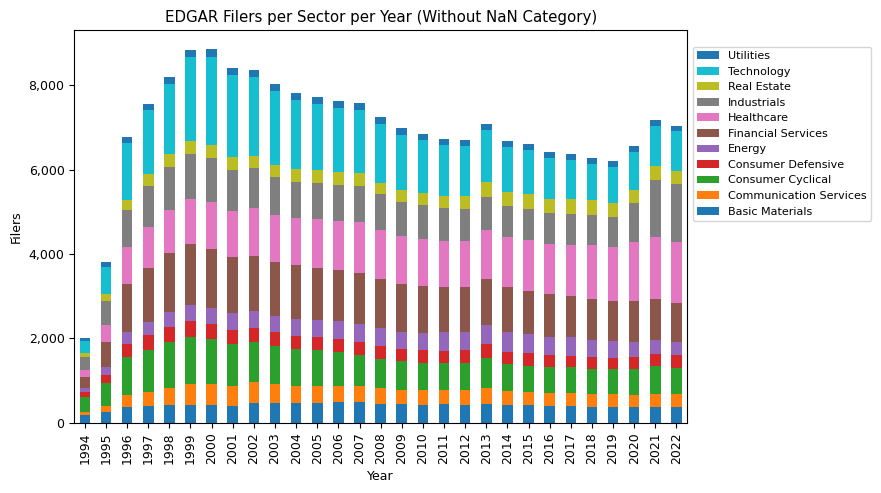

In [ ]:
sector_stats_pivot.drop(columns=[np.nan]).plot(kind='bar', stacked=True, figsize=(7, 5))
plt.title("EDGAR Filers per Sector per Year (Without NaN Category)")
plt.ylabel("Filers"), plt.xlabel("Year"), plt.tight_layout()
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='lower left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

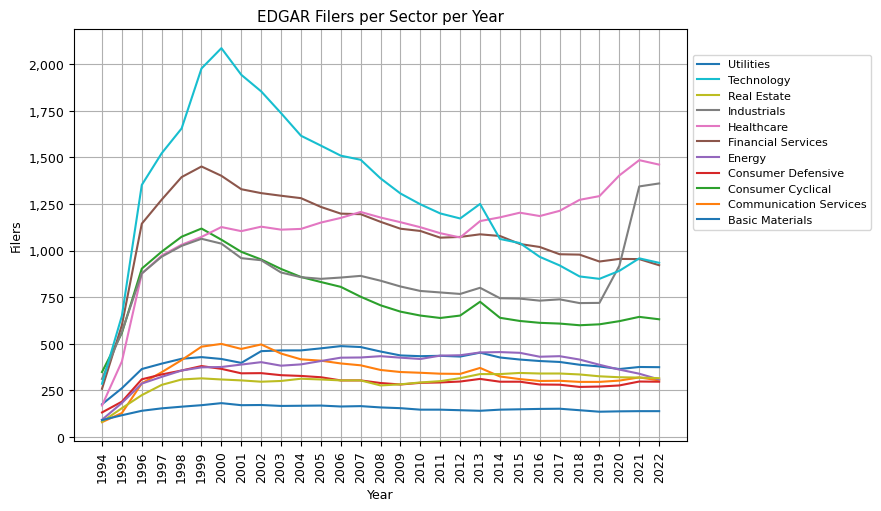

In [ ]:
sector_stats_pivot.drop(columns=[np.nan]).plot(kind='line', figsize=(7, 5))
plt.title("EDGAR Filers per Sector per Year")
plt.ylabel("Filers"), plt.xlabel("Year"), plt.tight_layout(), plt.grid(True), plt.gca().set_axisbelow(True)
plt.xticks(sector_stats_pivot.index, rotation=90)
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='lower left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

From the visual representation of the EDGAR filers per sector over time, we can derive the following key insights:

1. **Technology Boom and Subsequent Stabilization**: The Technology sector experienced a significant rise in the number of filers from 1996 to 2000, likely corresponding to the dot-com boom. However, after 2000, there was a decline, and then the number of filers stabilized and even increased slightly in the most recent years.

2. **Financial Services Peak and Decline**: The Financial Services sector saw a steady increase in the number of filers up to around 1999, after which there was a gradual decline, with minor fluctuations in the subsequent years.

3. **Healthcare's Consistent Rise**: The Healthcare sector has experienced a consistent increase in the number of filers over the years, with notable growth in the most recent years.

4. **Consumer Cyclical Variability**: The Consumer Cyclical sector experienced a steady rise until around 1999, followed by a decline. The sector has seen fluctuations but remains one of the larger sectors in terms of filers.

5. **Stability in Utilities**: The Utilities sector has remained relatively stable over the years in terms of the number of filers.

6. **Industrials' Recent Surge**: The Industrials sector has seen a significant rise in the number of filers in the last couple of years, indicating recent activity or interest in this sector.

7. **General Sector Trends**: Most sectors experienced growth in the number of filers during the mid to late 90s, followed by stabilization or slight decline in the 2000s. The past decade has seen either stabilization or growth for many sectors, with some exceptions.

8. **Smallest Sectors**: Communication Services and Real Estate have consistently been among the sectors with the lowest number of filers, though they too have experienced fluctuations over the years.

9. **Impact of Global Events**: Notable declines in many sectors can be observed around 2008, likely corresponding to the global financial crisis.

These insights provide a high-level view of the trends and shifts in the different sectors over the years based on the EDGAR filers' data. Further analysis could delve deeper into the reasons behind these trends, especially the recent surge in the Industrials sector.

In [ ]:
sector_stats_new_filers = new_filers.groupby(['year', 'sector'], dropna=False).cik.count().reset_index(name='cik_count')
sector_stats_new_filers[sector_stats_new_filers['year'] == 2022].sort_values(by='cik_count', ascending=False).head(20)

,year,sector,cik_count
346,2022,NaN,48522
342,2022,Industrials,51
341,2022,Healthcare,21
344,2022,Technology,21
337,2022,Consumer Cyclical,18
335,2022,Basic Materials,11
336,2022,Communication Services,9
339,2022,Energy,9
340,2022,Financial Services,8
338,2022,Consumer Defensive,7


In [ ]:
sector_stats_new_filers_pivot = sector_stats_new_filers.pivot(index='year', columns='sector', values='cik_count')
sector_stats_new_filers_pivot.fillna(0, inplace=True)
sector_stats_new_filers_pivot = sector_stats_new_filers_pivot.astype(int)
sector_stats_new_filers_pivot[-5:]

sector,NaN,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
year,,,,,,,,,,,,
2018,31920,10,14,33,11,10,31,81,21,7,32,3
2019,31539,11,15,24,17,7,25,71,21,7,44,2
2020,34426,10,22,56,21,1,45,147,225,11,85,6
2021,52907,15,26,50,24,8,34,96,456,5,83,9
2022,48522,11,9,18,7,9,8,21,51,3,21,2


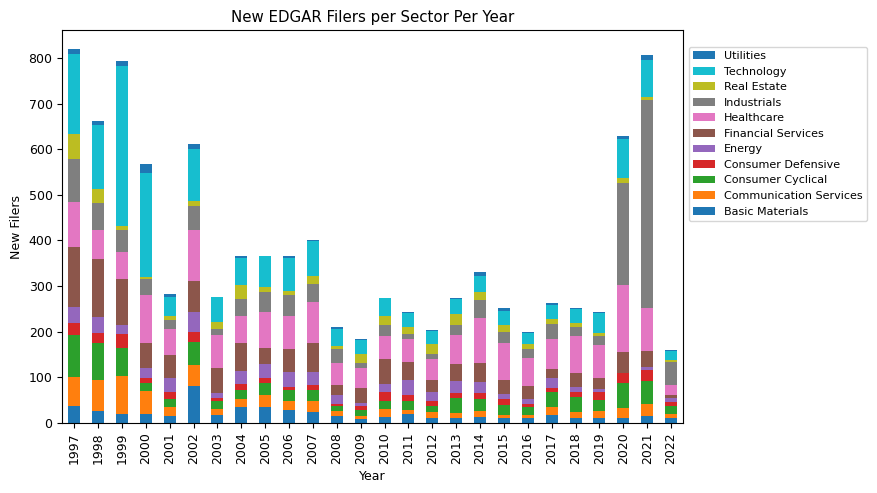

In [ ]:
sector_stats_new_filers_pivot.loc[1997:, :].drop(columns=[np.nan]).plot(kind='bar', stacked=True, figsize=(7, 5))
plt.title("New EDGAR Filers per Sector Per Year"), plt.ylabel("New Filers"), plt.xlabel("Year"), plt.tight_layout()
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='lower left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

### Industry-Level Analysis

Building on our sectorial analysis, we now narrow our focus to the industry level, offering a more granular perspective on the landscape of EDGAR filers over last three decades.

While bar charts will provide a clear representation of the data, we'll also introduce heatmaps to capture and visualize correlations between industries. Such visual tools offer a nuanced understanding of industry interplay and their respective prominence over time.

In [ ]:
industry_stats = entities.groupby(['year', 'industry'], dropna=False).cik.count().reset_index(name='cik_count')
industry_stats[industry_stats['year'] == 2022].sort_values(by='cik_count', ascending=False).head(10)

,year,industry,cik_count
4360,2022,NaN,151476
4230,2022,Biotechnology,831
4334,2022,Shell Companies,644
4226,2022,Banks - Regional,417
4336,2022,Software - Application,317
4292,2022,Medical Devices,181
4337,2022,Software - Infrastructure,165
4220,2022,Asset Management,141
4252,2022,Drug Manufacturers - Specialty & Generic,115
4298,2022,Oil & Gas E&P,103


In [ ]:
print('Number of industries:', len(industry_stats['industry'].unique()))

Number of industries: 154


In [ ]:
industry_stats_pivot = industry_stats.pivot(index='year', columns='industry', values='cik_count')
industry_stats_pivot.fillna(0, inplace=True)
industry_stats_pivot = industry_stats_pivot.astype(int)
industry_stats_pivot[-5:]

industry,NaN,Advertising Agencies,Aerospace & Defense,Agricultural Inputs,Airlines,Airports & Air Services,Aluminum,Apparel Manufacturing,Apparel Retail,Asset Management,...,Travel Services,Trucking,Uranium,Utilities - Diversified,Utilities - Independent Power Producers,Utilities - Regulated Electric,Utilities - Regulated Gas,Utilities - Regulated Water,Utilities - Renewable,Waste Management
year,,,,,,,,,,,,,,,,,,,,,
2018,126555,41,64,22,24,10,6,25,46,136,...,15,21,10,14,9,68,23,17,12,25
2019,127300,42,64,17,24,10,6,23,43,137,...,20,21,10,14,8,62,20,18,13,29
2020,128845,45,73,17,25,10,6,22,44,145,...,21,23,8,15,9,60,19,16,18,30
2021,153015,52,79,17,25,12,6,25,41,149,...,20,21,9,15,7,57,19,17,23,27
2022,151476,51,79,19,25,12,6,23,37,141,...,18,22,10,15,7,56,19,16,25,26


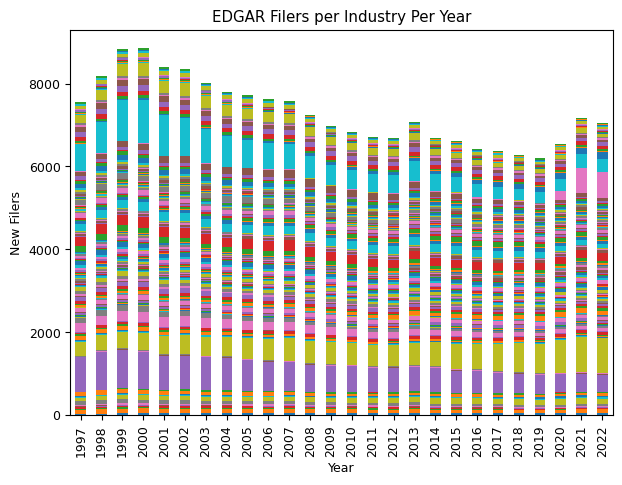

In [ ]:
industry_stats_pivot.loc[1997:, :].drop(columns=[np.nan]).plot(kind='bar', stacked=True, figsize=(7, 5))
plt.title("EDGAR Filers per Industry Per Year")
plt.ylabel("New Filers"), plt.xlabel("Year"), plt.legend().set_visible(False)
plt.show()

In [ ]:
industry_stats_new_filers = new_filers.groupby(['year', 'industry'], dropna=False).cik.count().reset_index(name='cik_count')
industry_stats_pivot_new_filers = industry_stats_new_filers.pivot(index='year', columns='industry', values='cik_count')
industry_stats_pivot_new_filers.fillna(0, inplace=True)
industry_stats_pivot_new_filers = industry_stats_pivot_new_filers.astype(int)
industry_stats_pivot_new_filers[-5:]

industry,NaN,Advertising Agencies,Aerospace & Defense,Agricultural Inputs,Airlines,Airports & Air Services,Aluminum,Apparel Manufacturing,Apparel Retail,Asset Management,...,Travel Services,Trucking,Uranium,Utilities - Diversified,Utilities - Independent Power Producers,Utilities - Regulated Electric,Utilities - Regulated Gas,Utilities - Regulated Water,Utilities - Renewable,Waste Management
year,,,,,,,,,,,,,,,,,,,,,
2018,31920,1,0,2,1,1,0,1,0,3,...,0,0,1,0,0,0,2,0,1,1
2019,31539,2,3,2,0,1,0,0,1,5,...,0,1,0,0,0,0,1,0,1,2
2020,34426,3,9,1,0,2,0,0,1,10,...,2,1,0,1,0,0,0,0,5,0
2021,52907,7,9,0,0,2,0,2,1,8,...,0,0,0,0,0,0,1,1,7,2
2022,48522,1,2,2,0,1,0,0,0,1,...,0,1,1,0,0,0,0,0,2,2


In [ ]:
top_10_industries = {}
for year in range(1994, 2023):
    top_10_industries[year] = industry_stats_new_filers[industry_stats_new_filers['year'] == year].sort_values(by='cik_count', ascending=False).head(20)
    top_10_industries[year] = top_10_industries[year][top_10_industries[year]['cik_count'] > 15]

top_10_industries_df = pd.concat(top_10_industries, axis=0)
top_10_industries_df.reset_index(inplace=True)
top_10_industries_df.drop(columns=['level_0', 'level_1'], inplace=True)
top_10_industries_df['year'] = top_10_industries_df['year'].astype(int)
top_10_industries_df

,year,industry,cik_count
0,1994,NaN,9915
1,1994,Banks - Regional,137
2,1994,Software - Application,65
3,1994,Biotechnology,63
4,1994,Specialty Industrial Machinery,59
...,...,...,...
171,2021,Software - Application,38
172,2021,Software - Infrastructure,22
173,2021,Banks - Regional,16
174,2022,NaN,48522


In [ ]:
top_10_industries_df = top_10_industries_df['industry'].unique().tolist()

In [ ]:
industry_stats_pivot_new_filers_top_10 = industry_stats_pivot_new_filers[top_10_industries_df]

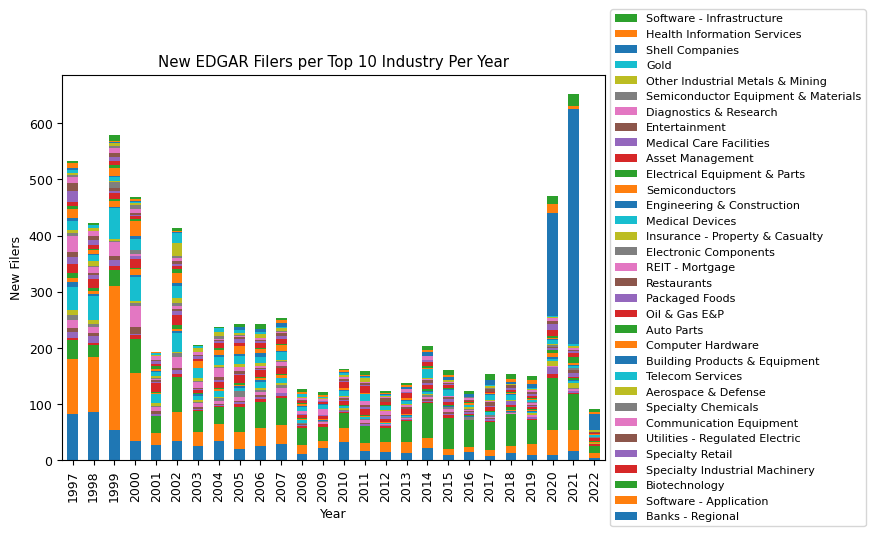

In [ ]:
industry_stats_pivot_new_filers_top_10.loc[1997:, :].drop(columns=[np.nan]).plot(kind='bar', stacked=True, figsize=(7, 5))
plt.title("New EDGAR Filers per Top 10 Industry Per Year"), plt.ylabel("New Filers"), plt.xlabel("Year")
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

In [ ]:
industry_stats_pivot_new_filers_top_10_pct_change = industry_stats_pivot_new_filers_top_10.pct_change() * 100
industry_stats_pivot_new_filers_top_10_pct_change = industry_stats_pivot_new_filers_top_10_pct_change.iloc[1:, :]
industry_stats_pivot_new_filers_top_10_pct_change = industry_stats_pivot_new_filers_top_10_pct_change.replace([np.inf, -np.inf], 0)
industry_stats_pivot_new_filers_top_10_pct_change = industry_stats_pivot_new_filers_top_10_pct_change.iloc[:, 1:]
industry_stats_pivot_new_filers_top_10_pct_change = industry_stats_pivot_new_filers_top_10_pct_change.reindex(sorted(industry_stats_pivot_new_filers_top_10_pct_change.columns), axis=1)
industry_stats_pivot_new_filers_top_10_pct_change[-5:]

industry,Aerospace & Defense,Asset Management,Auto Parts,Banks - Regional,Biotechnology,Building Products & Equipment,Communication Equipment,Computer Hardware,Diagnostics & Research,Electrical Equipment & Parts,...,Semiconductor Equipment & Materials,Semiconductors,Shell Companies,Software - Application,Software - Infrastructure,Specialty Chemicals,Specialty Industrial Machinery,Specialty Retail,Telecom Services,Utilities - Regulated Electric
year,,,,,,,,,,,,,,,,,,,,,
2018,-100.000000,50.000000,150.000000,62.500000,12.000000,0.000000,0.000000,100.0,0.0,200.000000,...,-100.0,0.000000,-66.666667,30.000000,-18.181818,-50.0,-50.000000,-100.000000,-100.000000,-100.0
2019,0.000000,66.666667,-60.000000,-30.769231,-23.214286,100.000000,200.000000,0.0,300.0,-66.666667,...,NaN,0.000000,166.666667,46.153846,-22.222222,-50.0,100.000000,0.000000,0.000000,NaN
2020,200.000000,100.000000,150.000000,0.000000,116.279070,50.000000,-66.666667,300.0,25.0,300.000000,...,NaN,200.000000,2212.500000,136.842105,85.714286,0.0,200.000000,225.000000,200.000000,NaN
2021,0.000000,-20.000000,-40.000000,77.777778,-31.182796,-66.666667,200.000000,-87.5,-40.0,150.000000,...,0.0,33.333333,125.945946,-15.555556,69.230769,100.0,-66.666667,-76.923077,33.333333,NaN
2022,-77.777778,-87.500000,-33.333333,-75.000000,-79.687500,-100.000000,-66.666667,0.0,-100.0,-100.000000,...,-100.0,-50.000000,-93.062201,-76.315789,-77.272727,-100.0,0.000000,-100.000000,-100.000000,NaN


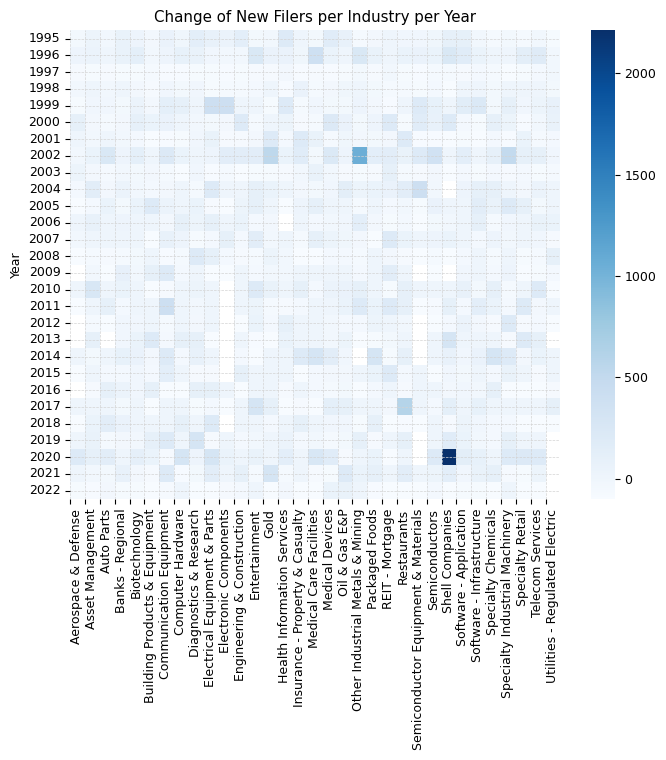

In [ ]:
sns.heatmap(industry_stats_pivot_new_filers_top_10_pct_change, cmap='Blues')
plt.gcf().set_size_inches(7, 7), plt.title("Change of New Filers per Industry per Year")
plt.ylabel("Year"), plt.xlabel(""), plt.tight_layout(), plt.grid(color='lightgrey', linestyle='dashed', linewidth=0.5)
ax = plt.gca()
ax.tick_params(axis='x', rotation=50), ax.set_xticklabels(ax.get_xticklabels(), ha='left')
plt.xticks(np.arange(len(industry_stats_pivot_new_filers_top_10_pct_change.columns)), industry_stats_pivot_new_filers_top_10_pct_change, rotation=90)
plt.yticks(np.arange(0.5, len(industry_stats_pivot_new_filers_top_10_pct_change.loc[1995:, :].index), 1), industry_stats_pivot_new_filers_top_10_pct_change.loc[1995:, :].index, rotation=0)
plt.show()

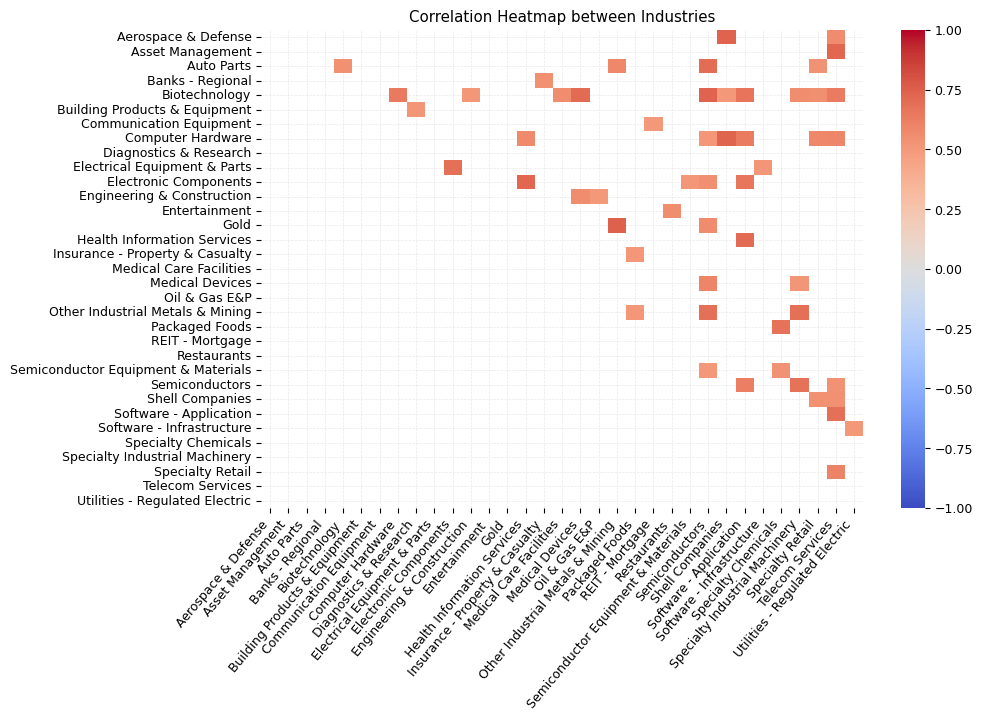

In [ ]:
industry_stats_pivot_new_filers_top_10_corr = industry_stats_pivot_new_filers_top_10_pct_change.corr()
industry_stats_pivot_new_filers_top_10_corr = industry_stats_pivot_new_filers_top_10_corr[(industry_stats_pivot_new_filers_top_10_corr > 0.5) | (industry_stats_pivot_new_filers_top_10_corr < -0.5)]
# hide all values below the diagonal
mask = np.tril(np.ones_like(industry_stats_pivot_new_filers_top_10_corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(industry_stats_pivot_new_filers_top_10_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, mask=mask)
plt.title('Correlation Heatmap between Industries'), plt.tight_layout(), plt.gcf().set_size_inches(10, 7)
plt.ylabel(''), plt.xlabel('')
plt.gca().xaxis.grid(color='lightgrey', linestyle='dashed', linewidth=0.5, which='major', alpha=0.5)
plt.gca().yaxis.grid(color='lightgrey', linestyle='dashed', linewidth=0.5, which='major', alpha=0.5)
plt.gca().set_axisbelow(True)
ax = plt.gca()
ax.tick_params(axis='x', rotation=50), ax.set_xticklabels(ax.get_xticklabels(), ha='right')
plt.show()

In [ ]:
most_correlated_industries = industry_stats_pivot_new_filers_top_10_corr.sum().sort_values(ascending=False).head(10)
print('Top 10 industries correlated the most with the other industries')
print('-'*70)
most_correlated_industries

Top 10 industries correlated the most with the other industries
----------------------------------------------------------------------


industry
Semiconductors                      7.680265
Biotechnology                       7.614659
Telecom Services                    5.887208
Computer Hardware                   5.270098
Software - Application              4.974338
Other Industrial Metals & Mining    4.202393
Electronic Components               4.129252
Shell Companies                     4.060234
Specialty Retail                    3.819267
Specialty Industrial Machinery      3.433053
dtype: float64

## EDGAR Entities by SIC and SEC Office

We now turn our attention to two key categorizations: the Standard Industrial Classification (SIC) codes and the designated SEC Offices. While SIC codes offer insights into the primary business activities of these entities, the SEC Offices provide an organizational perspective on how the SEC manages and oversees these entities.

**SEC Offices Overview**:
There are 12 distinct SEC Offices responsible for different sectors and industries. These are:

- Industrial Applications and Services
- Energy & Transportation
- Finance
- International Corp Fin
- Life Sciences
- Manufacturing
- Real Estate & Construction
- Structured Finance
- Technology
- Trade & Services
- Crypto Assets (Note: Some entities fall under both "Finance" and "Crypto Assets")

**SIC Codes Overview**:
The SIC system classifies 444 industries using a unique 3 or 4 digit code. For instance, while code 7374 represents Computer Processing & Data Preparation, another code like 2834 denotes Pharmaceutical Preparations.

In this section, we will analyze and visualize the distribution of EDGAR entities based on their SIC codes and the SEC Offices they fall under, focusing especially on the trends over the past three decades.

In [ ]:
office_stats = entities.groupby(['year', 'office'], dropna=False).cik.count().reset_index(name='cik_count')
office_stats

,year,office,cik_count
0,1994,Industrial Applications and Services,315
1,1994,Office of Energy & Transportation,561
2,1994,Office of Finance,514
3,1994,Office of Finance or Office of Crypto Assets,11
4,1994,Office of International Corp Fin,1
...,...,...,...
369,2022,Office of Real Estate & Construction,1928
370,2022,Office of Structured Finance,1115
371,2022,Office of Technology,1256
372,2022,Office of Trade & Services,1683


In [ ]:
office_stats_pivot = office_stats.pivot(index='year', columns='office', values='cik_count')
office_stats_pivot.fillna(0, inplace=True)
office_stats_pivot = office_stats_pivot.astype(int)
office_stats_pivot[-5:]

office,NaN,Industrial Applications and Services,Office of Crypto Assets,Office of Energy & Transportation,Office of Finance,Office of Finance or Office of Crypto Assets,Office of International Corp Fin,Office of Life Sciences,Office of Manufacturing,Office of Real Estate & Construction,Office of Structured Finance,Office of Technology,Office of Trade & Services
year,,,,,,,,,,,,,
2018,121938,878,107,1490,1168,61,109,856,1324,1215,1099,1129,1452
2019,122498,894,98,1416,1121,74,177,917,1278,1227,1065,1141,1588
2020,124483,860,84,1290,1094,74,98,976,1264,1485,1067,1092,1526
2021,148335,948,91,1285,1113,97,101,1110,1299,1916,1095,1198,1598
2022,146558,942,89,1196,1079,123,91,1173,1284,1928,1115,1256,1683


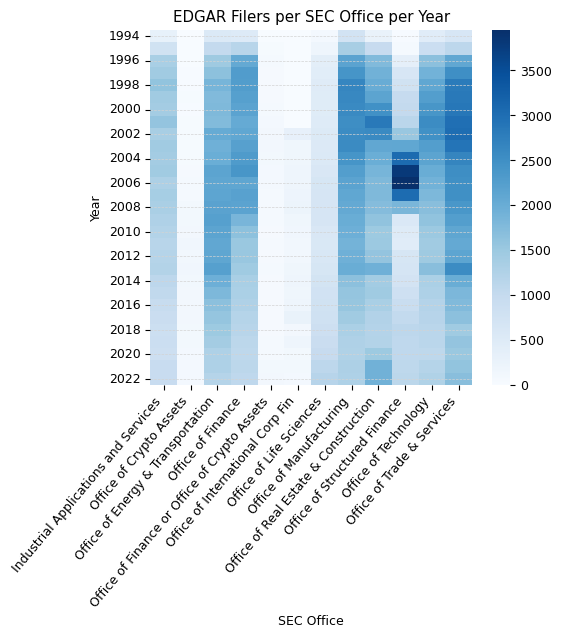

In [ ]:
sns.heatmap(office_stats_pivot.drop(columns=[np.nan]), cmap='Blues')
plt.gcf().set_size_inches(5, 7)
plt.title("EDGAR Filers per SEC Office per Year"), plt.ylabel("Year"), plt.xlabel("SEC Office")
plt.tight_layout(), plt.gca().yaxis.grid(color='lightgrey', linestyle='dashed', linewidth=0.5)
ax = plt.gca()
ax.tick_params(axis='x', rotation=50), ax.set_xticklabels(ax.get_xticklabels(), ha='right')
plt.show()

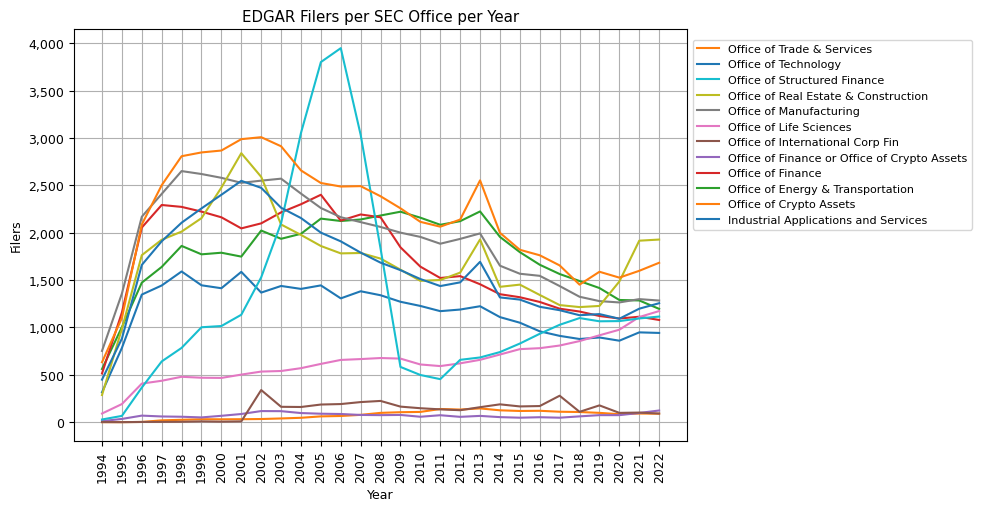

In [ ]:
office_stats_pivot.drop(columns=[np.nan]).plot(kind='line', figsize=(7, 5))
plt.title("EDGAR Filers per SEC Office per Year")
plt.ylabel("Filers"), plt.xlabel("Year"), plt.tight_layout(), plt.grid(True), plt.gca().set_axisbelow(True)
plt.xticks(sector_stats_pivot.index, rotation=90)
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='lower left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

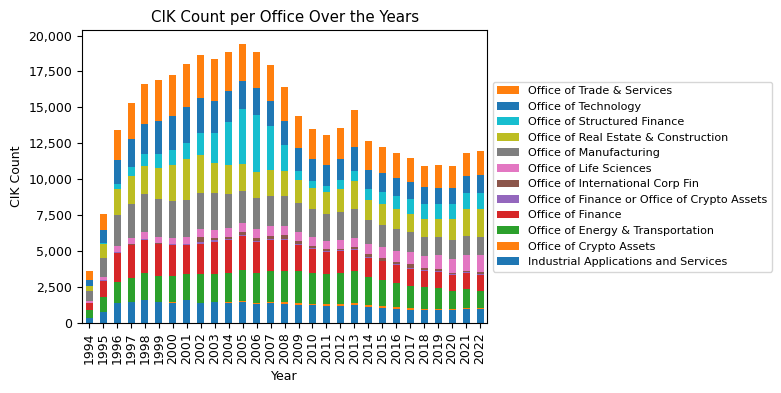

In [ ]:
office_stats_pivot.drop(columns=[np.nan]).plot(kind='bar', stacked=True, figsize=(5, 4))
plt.title("CIK Count per Office Over the Years"), plt.ylabel("CIK Count"), plt.xlabel("Year")
plt.tight_layout()
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

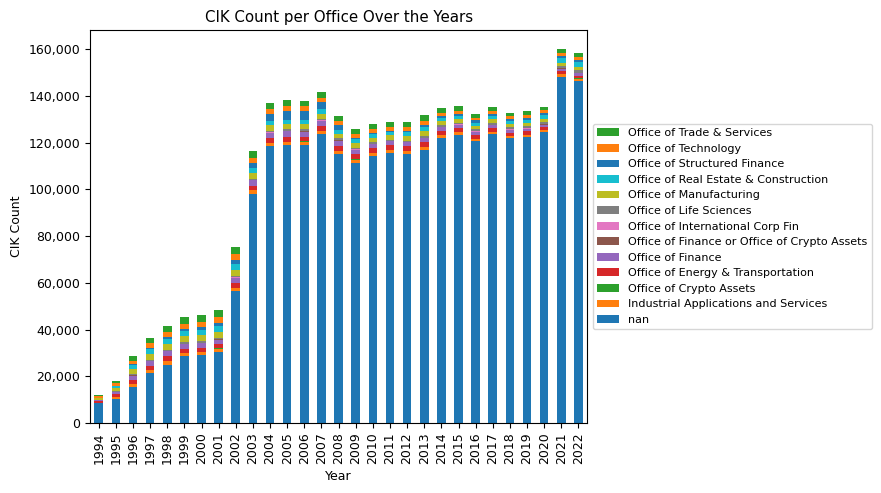

In [ ]:
office_stats_pivot.plot(kind='bar', stacked=True, figsize=(6, 5))
plt.title("CIK Count per Office Over the Years"), plt.ylabel("CIK Count"), plt.xlabel("Year")
plt.tight_layout()
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.show()

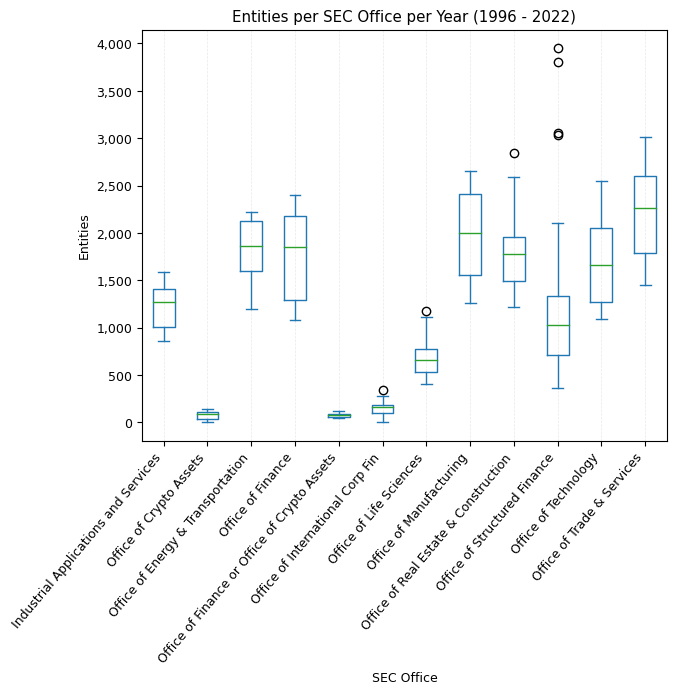

In [ ]:
office_stats_pivot.loc[1996:2022].drop(columns=[np.nan]).plot(kind='box', figsize=(7, 5))
plt.title("Entities per SEC Office per Year (1996 - 2022)"), plt.ylabel("Entities"), plt.xlabel("SEC Office"), plt.tight_layout()
ax = plt.gca()
ax.tick_params(axis='x', rotation=50), ax.set_xticklabels(ax.get_xticklabels(), ha='right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().xaxis.grid(color='lightgrey', linestyle='dashed', linewidth=0.5, which='major', alpha=0.5)
plt.show()

In analyzing the EDGAR filers per SEC Office over the years, several interesting trends emerge. First and foremost, it's evident that the majority of filers is not associated with a SIC code and therefore not associated with an SEC Office. Historically, in 1994, 70% of all filers were not associated with a SIC code. By 2022, this number has surged to 92%. Such a large proportion of filers not being associated with an SEC Office raises the question of who is responsible for overseeing these filers and their filings at the SEC.

To provide context, persons reporting security acquisitions/disposals (Form 3, 4, 5) are not associated with a SIC code. However, they are still mandated to file with the SEC and are subsequently included as an entity in the EDGAR filer data. Given that Form 3/4/5 filings account for around 25% of all filings filed annually, this might shed light on the high number of filers not associated with a SIC code. Yet, it only accounts for a fraction of the 92% of filers without a SIC code.

Delving deeper into specific SEC Offices, the Office of Life Sciences has shown consistent growth, while offices like the Office of Energy & Transportation, Office of Finance, and Office of Technology have seen a mostly consistent decline. The Office of Structured Finance, in particular, peaked around 2005 before witnessing a sharp decline and then stabilizing after 2010. On the other hand, the Office of Crypto Assets, starting from a modest base, has displayed growth, underscoring the rising interest or activity in crypto assets over the years. The dynamics of these trends reflect shifts in sectors or focus areas over the years and can be crucial for understanding the evolving landscape of financial filings.

In [ ]:
sic_stats = entities.groupby(['year', 'sic'], dropna=False).cik.count().reset_index(name='cik_count')
sic_stats_pivot = sic_stats.pivot(index='year', columns='sic', values='cik_count')
sic_stats_pivot.fillna(0, inplace=True)
sic_stats_pivot = sic_stats_pivot.loc[:, sic_stats_pivot.mean() >= 50]
sic_stats_pivot = sic_stats_pivot.astype(int)

In [ ]:
sic_stats_pivot[-5:]

sic,NaN,0000,1000 Metal Mining,1040 Gold and Silver Ores,1311 Crude Petroleum &amp; Natural Gas,1381 Drilling Oil &amp; Gas Wells,1382 Oil &amp; Gas Field Exploration Services,1400 Mining &amp; Quarrying of Nonmetallic Minerals (No Fuels),1531 Operative Builders,2834 Pharmaceutical Preparations,...,7372 Services-Prepackaged Software,7373 Services-Computer Integrated Systems Design,7374 Services-Computer Processing &amp; Data Preparation,"7389 Services-Business Services, NEC",7990 Services-Miscellaneous Amusement &amp; Recreation,8200 Services-Educational Services,8731 Services-Commercial Physical &amp; Biological Research,8742 Services-Management Consulting Services,8880 American Depositary Receipts,9995 Non-Operating Establishments
year,,,,,,,,,,,,,,,,,,,,,
2018,121854,83,143,116,318,40,40,47,55,658,...,307,59,125,194,33,49,39,79,68,9
2019,122429,69,134,133,285,40,34,49,46,693,...,333,53,131,207,38,57,37,75,136,12
2020,124425,58,111,113,243,31,25,43,55,715,...,323,46,140,194,47,61,34,73,56,16
2021,148279,56,107,120,243,34,34,39,50,797,...,375,48,167,212,44,72,36,69,56,18
2022,146489,69,102,119,197,26,25,37,28,835,...,405,53,176,219,48,76,32,76,46,8


In [ ]:
top_20_sics_2022 = sic_stats[sic_stats['year'] == 2022].sort_values(by='cik_count', ascending=False)[:10]
top_20_sics_2022

,year,sic,cik_count
12624,2022,NaN,146489
12536,2022,6189 Asset-Backed Securities,1115
12557,2022,6770 Blank Checks,1098
12287,2022,2834 Pharmaceutical Preparations,835
12578,2022,7372 Services-Prepackaged Software,405
12561,2022,6798 Real Estate Investment Trusts,390
12525,2022,6022 State Commercial Banks,253
12523,2022,"5990 Retail-Retail Stores, NEC",248
12289,2022,"2836 Biological Products, (No Diagnostic Subst...",240
12584,2022,"7389 Services-Business Services, NEC",219


In [ ]:
sic_stats_wo_nan = sic_stats_pivot.drop(columns=[np.nan, '0000'])

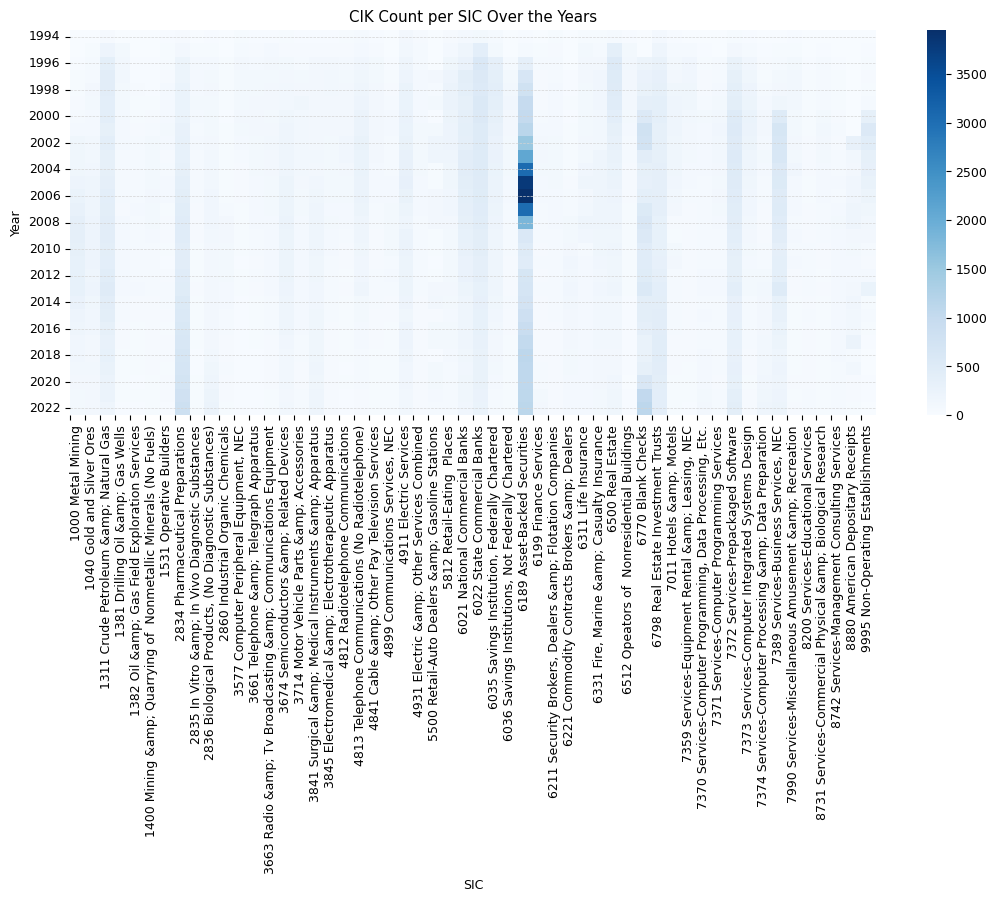

In [ ]:
sns.heatmap(sic_stats_wo_nan, cmap='Blues')
plt.gcf().set_size_inches(13, 5)
plt.title("CIK Count per SIC Over the Years"), plt.ylabel("Year"), plt.xlabel("SIC")
plt.gca().yaxis.grid(color='lightgrey', linestyle='dashed', linewidth=0.5)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), ha='left')
plt.xticks(np.arange(len(sic_stats_wo_nan.columns)), sic_stats_wo_nan, rotation=90)
plt.show()

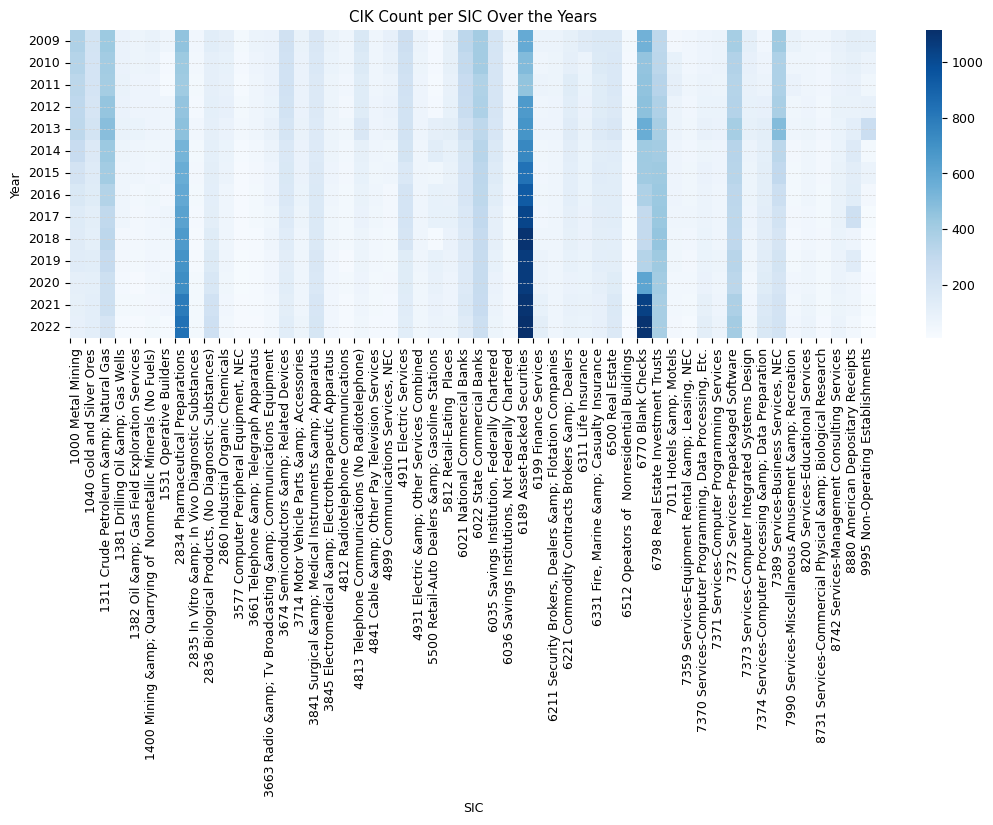

In [ ]:
sns.heatmap(sic_stats_wo_nan.loc[2009:2022], cmap='Blues')
plt.gcf().set_size_inches(13, 4)
plt.title("CIK Count per SIC Over the Years"), plt.ylabel("Year"), plt.xlabel("SIC")
plt.gca().yaxis.grid(color='lightgrey', linestyle='dashed', linewidth=0.5)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), ha='left')
plt.xticks(np.arange(len(sic_stats_wo_nan.columns)), sic_stats_wo_nan, rotation=90)
plt.show()